<a href="https://colab.research.google.com/github/vsmacedo-datafinance/Challenge_Locaweb_FIAP_2026/blob/main/notebooks/04_Sarimax_Previs%C3%A3o_de_Volume.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Projeto Chronos**
##CHALLENGE LOCAWEB 2026
Integrantes:

* Bruno Rosa - RM563779
* Danilo Alves - RM564109
* Enzo Cremaschi - RM562058
* Vinícius Macedo - RM561911

# 04 — Desafio 1: Previsão de Volume (SARIMAX) | Projeto Chronos

**Premissas assumidas:**
-  **Abordagem Bottom-Up**: P2 (Alta) e P3 (Média) têm comportamento diferente — em vez de modelar a soma direto, treinamos **um modelo para cada prioridade** e somamos as previsões no final. A ideia: cada modelo aprende a curva específica da sua prioridade, em vez de uma curva combinada que borra os dois padrões.
- **Métricas robustas** (MedAE/MdAPE, mediana) ao lado das médias, para não deixar um único dia extremo distorcer a leitura de qual modelo é melhor.
- **Teste de parcimônia**: `dow_sin`/`dow_cos` estatisticamente irrelevantes (p=0,81 e p=0,98) — testamos remover.
- **Reteste da escala (bruta vs. `log1p`) nos 3 folds**, não só no fold contaminado pelo salto — com correção de viés de Duan na reversão do log (`np.expm1` sozinho subestima sistematicamente).
- **Diagnóstico formal de resíduos** (Ljung-Box, Jarque-Bera, Breusch-Pagan) e **intervalo de previsão por bootstrap dos resíduos**, como alternativa ao IC gaussiano — a curtose de 27,69 encontrada antes indica que a suposição de normalidade não se sustenta.

**Decisão de arquitetura**: as séries diárias de P2 e P3 (elegíveis para KPI) **não vêm de `gold_volume_diario`** — essa tabela só tem a soma de P2+P3, não separadas por prioridade.


Observação: destrinchamos o que é ruído, sazonalidade e padrão nas séries de P2 e P3, separadamente — com decomposição STL, ACF/PACF e a investigação de saltos anômalos.

**Desenho da validação:**
| Fold | Treino | Teste |
|---|---|---|
| 1 | semanas 01–30 | semanas 31–37 |
| 2 | semanas 01–37 | semanas 38–44 |
| 3 | semanas 01–44 | semanas 45–51 |

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import sys
sys.path.append('/content/drive/MyDrive/cronos_project')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import (
    setup_logging, PROJECT_PATHS, load_parquet_layer, generate_expanding_folds,
    calcular_metricas_serie, compute_all_baselines, baseline_rolling_mean,
    SPECS_SARIMAX_PADRAO, rodar_variante_sarimax, construir_exogenas_futuras,
    checar_faixa_kpi, FAIXAS_VOLUME_ANUAL_P2, FAIXAS_VOLUME_ANUAL_P3,
    detectar_saltos_anomalos, bootstrap_prediction_interval,
    log1p_bias_corrected_forecast, diagnostico_residuos, salvar_artefato,
    proporcao_elegivel_por_semana, detectar_censura_elegibilidade, validar_previsao_producao,
    avaliar_por_horizonte, bootstrap_prediction_interval_conjunto,
    taxa_violacao_historica_por_prioridade, projetar_ola_esperado,
    FAIXAS_OLA_QUEBRADO_ANUAL_P2, FAIXAS_OLA_QUEBRADO_ANUAL_P3,
)

logger = setup_logging('sarimax_bottomup')

In [3]:
!pip install pmdarima -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 34.7 MB/s eta 0:00:00


In [4]:
import pmdarima as pm
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

## Decisão de negócio — usar apenas o que entra em KPI

A decisão do grupo é **modelar exclusivamente a série elegível** — é o que a Locaweb monitora de fato e o que aparece nas metas anuais oficiais (Dicionário de Dados v2), ou seja, é o recorte que reflete a preocupação real do negócio. A série bruta continua sendo mostrada logo abaixo, como evidência que sustenta essa decisão, mas nunca alimenta nenhum modelo deste notebook.

In [5]:
USAR_APENAS_ELEGIVEL_KPI = True  # decisão de negócio: só o que entra em KPI — ver justificativa acima
MODO_DADOS = 'elegível para KPI'
logger.info('Modo de dados deste notebook: %s (decisão de negócio, não um parâmetro a testar).', MODO_DADOS)

2026-09-12 18:28:43 | INFO     | sarimax_bottomup | Modo de dados deste notebook: elegível para KPI (decisão de negócio, não um parâmetro a testar).


INFO:sarimax_bottomup:Modo de dados deste notebook: elegível para KPI (decisão de negócio, não um parâmetro a testar).


---
## PARTE 0 — Ruído, sazonalidade e padrão

A decomposição STL abaixo separa esses três componentes de forma visual e numérica — feita **separadamente para P2 e P3**, porque a hipótese de trabalho (a razão de fazer bottom-up) é que esses componentes têm peso diferente nas duas séries.


### 0.1 Carga das séries P2 e P3 — elegível e bruta, sempre as duas

2026-09-12 18:28:45 | INFO     | sarimax_bottomup | Lido de /content/drive/MyDrive/cronos_project/data/gold/gold_chamados_risco.parquet: 121811 linhas x 35 colunas (2 colunas de metadado: ['_ingested_at', '_source_layer']).


INFO:sarimax_bottomup:Lido de /content/drive/MyDrive/cronos_project/data/gold/gold_chamados_risco.parquet: 121811 linhas x 35 colunas (2 colunas de metadado: ['_ingested_at', '_source_layer']).


2026-09-12 18:28:46 | INFO     | sarimax_bottomup | Série P2 elegível: média 14.1/dia, total 5159 no ano.


INFO:sarimax_bottomup:Série P2 elegível: média 14.1/dia, total 5159 no ano.


2026-09-12 18:28:46 | INFO     | sarimax_bottomup | Série P3 elegível: média 54.8/dia, total 19997 no ano.


...

INFO:sarimax_bottomup:Série P3 bruta: média 113.0/dia, total 41260 no ano.


2026-09-12 18:28:46 | INFO     | sarimax_bottomup | Séries ativas para modelagem neste notebook: elegível para KPI.


INFO:sarimax_bottomup:Séries ativas para modelagem neste notebook: elegível para KPI.


2026-09-12 18:28:46 | INFO     | sarimax_bottomup | Lido de /content/drive/MyDrive/cronos_project/data/gold/gold_volume_diario.parquet: 365 linhas x 21 colunas (2 colunas de metadado: ['_ingested_at', '_source_layer']).


INFO:sarimax_bottomup:Lido de /content/drive/MyDrive/cronos_project/data/gold/gold_volume_diario.parquet: 365 linhas x 21 colunas (2 colunas de metadado: ['_ingested_at', '_source_layer']).


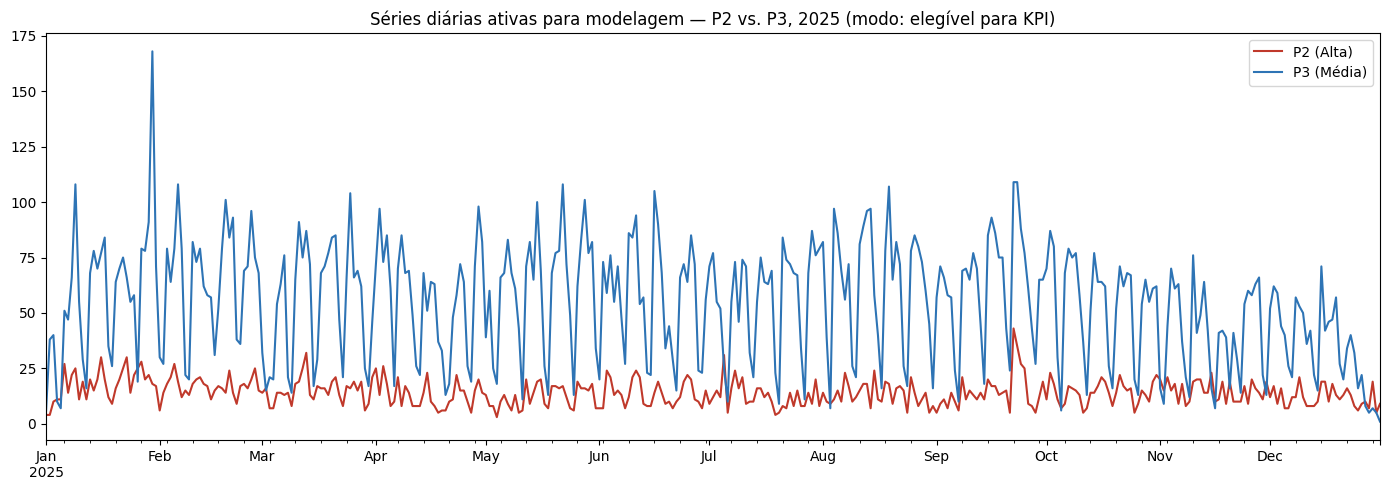

In [6]:
gold_risco_path = PROJECT_PATHS.gold / 'gold_chamados_risco.parquet'
df_risco = load_parquet_layer(gold_risco_path, logger=logger)
df_risco['Aberto'] = pd.to_datetime(df_risco['Aberto'])
df_risco['data'] = df_risco['Aberto'].dt.date

df_elegivel = df_risco[df_risco['Entrou para KPI?'] == 'SIM'].copy()

indice_completo = pd.date_range('2025-01-01', '2025-12-31', freq='D')

def carregar_serie_diaria(df_fonte, prioridade):
    serie = df_fonte[df_fonte['Prioridade'] == prioridade].groupby('data').size()
    serie.index = pd.to_datetime(serie.index)
    return serie.reindex(indice_completo, fill_value=0)

serie_p2_elegivel = carregar_serie_diaria(df_elegivel, '2 - Alta')
serie_p3_elegivel = carregar_serie_diaria(df_elegivel, '3 - Média')
serie_p2_bruta = carregar_serie_diaria(df_risco, '2 - Alta')
serie_p3_bruta = carregar_serie_diaria(df_risco, '3 - Média')

logger.info('Série P2 elegível: média %.1f/dia, total %d no ano.', serie_p2_elegivel.mean(), serie_p2_elegivel.sum())
logger.info('Série P3 elegível: média %.1f/dia, total %d no ano.', serie_p3_elegivel.mean(), serie_p3_elegivel.sum())
logger.info('Série P2 bruta: média %.1f/dia, total %d no ano.', serie_p2_bruta.mean(), serie_p2_bruta.sum())
logger.info('Série P3 bruta: média %.1f/dia, total %d no ano.', serie_p3_bruta.mean(), serie_p3_bruta.sum())

serie_p2 = serie_p2_elegivel if USAR_APENAS_ELEGIVEL_KPI else serie_p2_bruta
serie_p3 = serie_p3_elegivel if USAR_APENAS_ELEGIVEL_KPI else serie_p3_bruta
logger.info('Séries ativas para modelagem neste notebook: %s.', MODO_DADOS)

gold_volume_path = PROJECT_PATHS.gold / 'gold_volume_diario.parquet'
gold_volume_ref = load_parquet_layer(gold_volume_path, logger=logger)
gold_volume_ref['data'] = pd.to_datetime(gold_volume_ref['data'])
exogenas = gold_volume_ref.set_index('data')[['fim_de_semana', 'feriado', 'vespera_feriado', 'dia_seguinte_feriado', 'dow_sin', 'dow_cos']]
exogenas = exogenas.reindex(indice_completo)

fig, ax = plt.subplots(figsize=(14, 5))
serie_p2.plot(ax=ax, label='P2 (Alta)', color='#c0392b')
serie_p3.plot(ax=ax, label='P3 (Média)', color='#2E74B5')
ax.legend()
ax.set_title(f'Séries diárias ativas para modelagem — P2 vs. P3, 2025 (modo: {MODO_DADOS})')
plt.tight_layout()
plt.show()

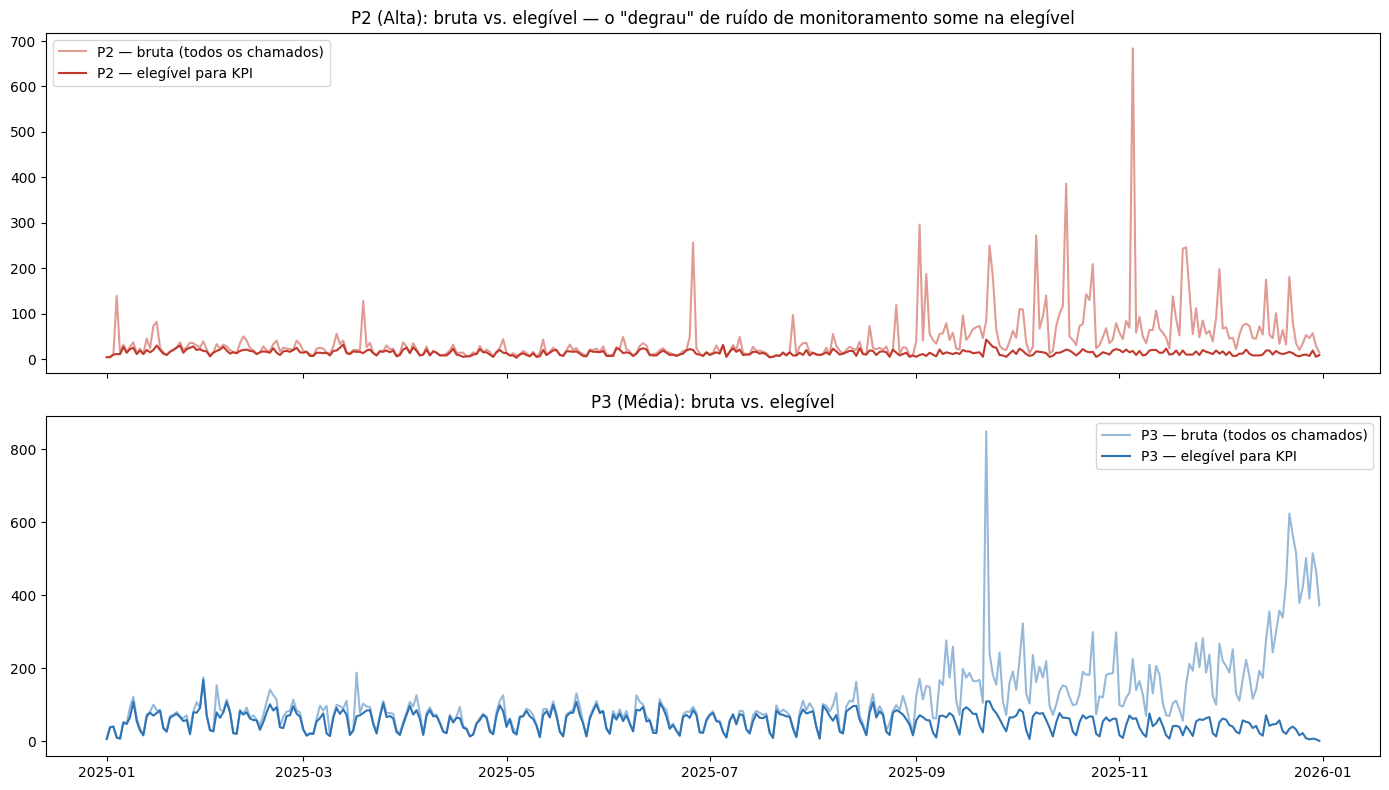

2026-09-12 18:28:48 | INFO     | sarimax_bottomup | P2: a série bruta tem 3.0x mais chamados que a elegível no ano.


INFO:sarimax_bottomup:P2: a série bruta tem 3.0x mais chamados que a elegível no ano.


2026-09-12 18:28:48 | INFO     | sarimax_bottomup | P3: a série bruta tem 2.1x mais chamados que a elegível no ano.


INFO:sarimax_bottomup:P3: a série bruta tem 2.1x mais chamados que a elegível no ano.


2026-09-12 18:28:48 | INFO     | sarimax_bottomup | Decisão de negócio confirmada: modelando apenas a série elegível para KPI.


INFO:sarimax_bottomup:Decisão de negócio confirmada: modelando apenas a série elegível para KPI.


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(serie_p2_bruta.index, serie_p2_bruta.values, label='P2 — bruta (todos os chamados)', color='#c0392b', alpha=0.5)
axes[0].plot(serie_p2_elegivel.index, serie_p2_elegivel.values, label='P2 — elegível para KPI', color='#c0392b')
axes[0].legend()
axes[0].set_title('P2 (Alta): bruta vs. elegível — o "degrau" de ruído de monitoramento some na elegível')

axes[1].plot(serie_p3_bruta.index, serie_p3_bruta.values, label='P3 — bruta (todos os chamados)', color='#2E74B5', alpha=0.5)
axes[1].plot(serie_p3_elegivel.index, serie_p3_elegivel.values, label='P3 — elegível para KPI', color='#2E74B5')
axes[1].legend()
axes[1].set_title('P3 (Média): bruta vs. elegível')

plt.tight_layout()
plt.show()

razao_p2 = serie_p2_bruta.sum() / serie_p2_elegivel.sum()
razao_p3 = serie_p3_bruta.sum() / serie_p3_elegivel.sum()
logger.info('P2: a série bruta tem %.1fx mais chamados que a elegível no ano.', razao_p2)
logger.info('P3: a série bruta tem %.1fx mais chamados que a elegível no ano.', razao_p3)
logger.info('Decisão de negócio confirmada: modelando apenas a série %s.', MODO_DADOS)

### 0.2 Decomposição STL — separando tendência, sazonalidade e resíduo

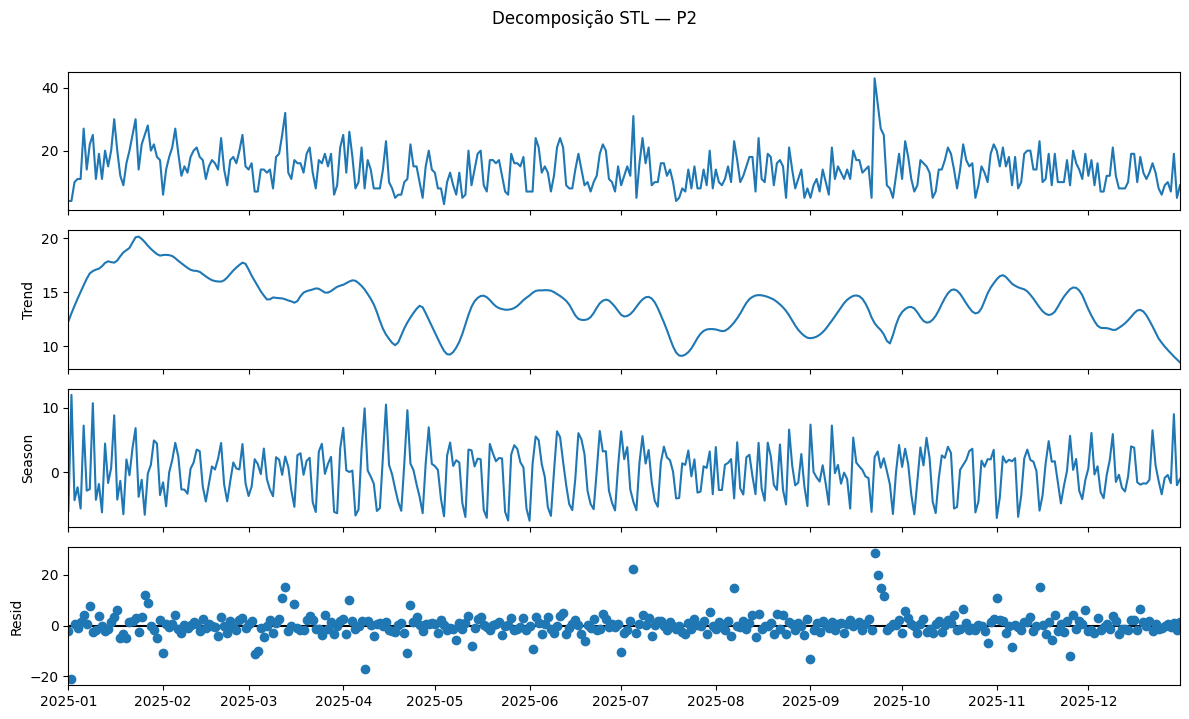

2026-09-12 18:28:51 | INFO     | sarimax_bottomup | P2: força da sazonalidade=0.332 | força da tendência=0.231 (0=ausente, 1=domina)


INFO:sarimax_bottomup:P2: força da sazonalidade=0.332 | força da tendência=0.231 (0=ausente, 1=domina)


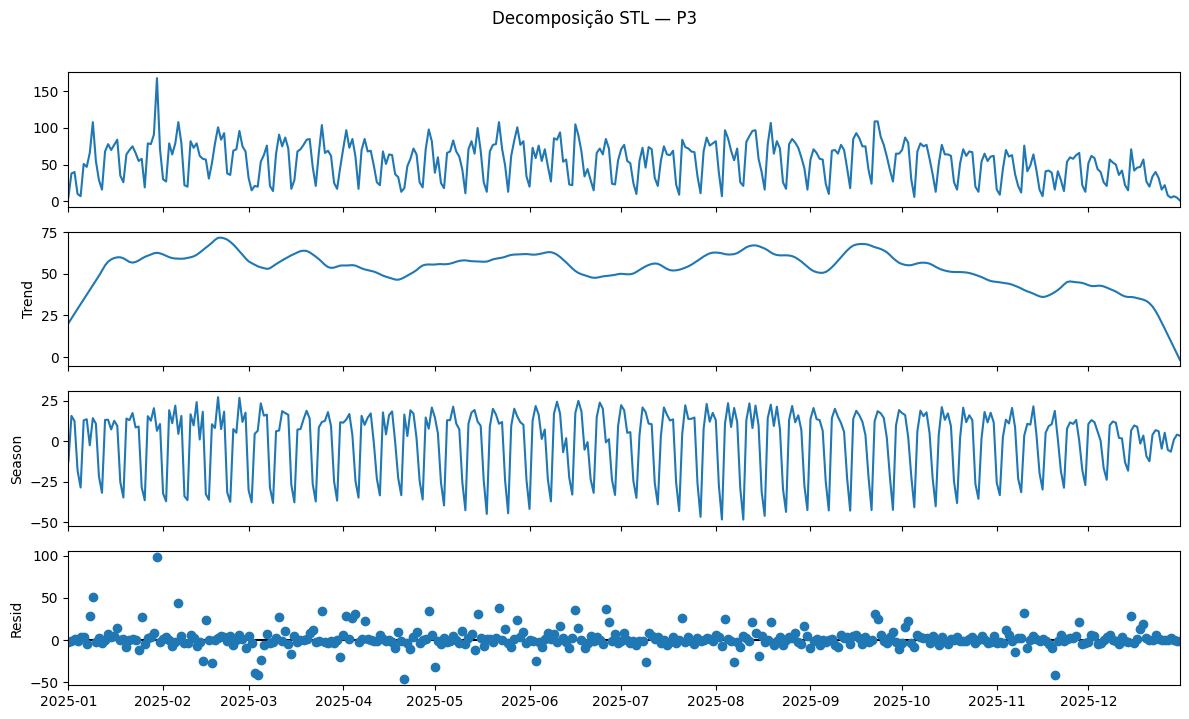

2026-09-12 18:28:54 | INFO     | sarimax_bottomup | P3: força da sazonalidade=0.737 | força da tendência=0.461 (0=ausente, 1=domina)


INFO:sarimax_bottomup:P3: força da sazonalidade=0.737 | força da tendência=0.461 (0=ausente, 1=domina)


In [8]:
SERIES = {'P2': serie_p2, 'P3': serie_p3}
resultados_stl = {}

for nome, serie in SERIES.items():
    stl = STL(serie, period=7, robust=True)
    resultado = stl.fit()
    resultados_stl[nome] = resultado

    fig = resultado.plot()
    fig.set_size_inches(12, 7)
    fig.suptitle(f'Decomposição STL — {nome}', y=1.02)
    plt.tight_layout()
    plt.show()

    forca_sazonalidade = max(0, 1 - resultado.resid.var() / (resultado.seasonal + resultado.resid).var())
    forca_tendencia = max(0, 1 - resultado.resid.var() / (resultado.trend + resultado.resid).var())
    logger.info('%s: força da sazonalidade=%.3f | força da tendência=%.3f (0=ausente, 1=domina)', nome, forca_sazonalidade, forca_tendencia)

### 0.3 ACF/PACF — o padrão de autocorrelação de cada série

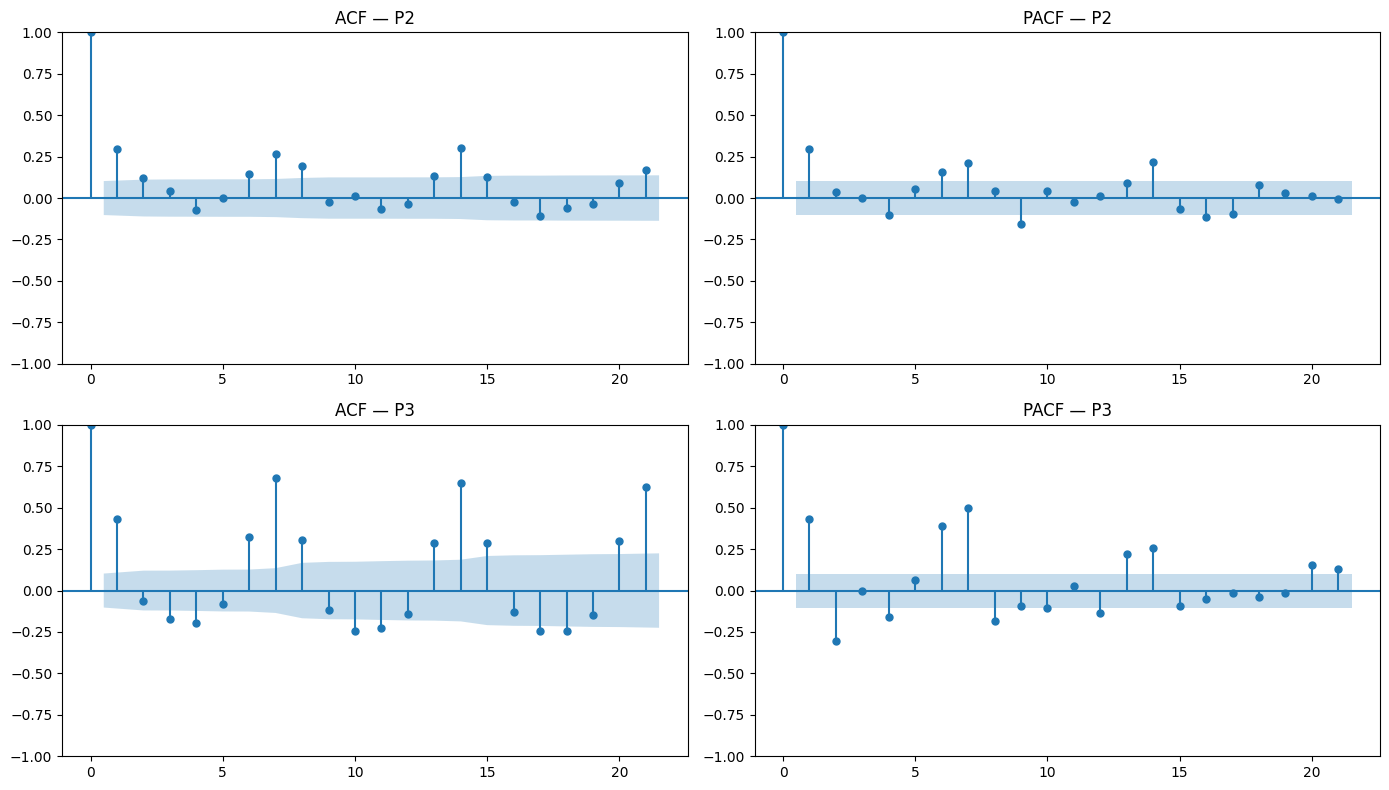

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for i, (nome, serie) in enumerate(SERIES.items()):
    plot_acf(serie, lags=21, ax=axes[i, 0], title=f'ACF — {nome}')
    plot_pacf(serie, lags=21, ax=axes[i, 1], title=f'PACF — {nome}')
plt.tight_layout()
plt.show()

### 0.4 Investigação de saltos anômalos (ruído) — separada por prioridade

Checagem se os mesmos dias aparecem como anômalos nas duas prioridades, ou se é um fenômeno específico de uma delas.

In [10]:
saltos_por_serie = {}
for nome, serie in SERIES.items():
    saltos = detectar_saltos_anomalos(serie, limiar_desvios=3.0)
    saltos_por_serie[nome] = saltos
    logger.info('%s: %d saltos anômalos detectados.', nome, len(saltos))
    if len(saltos):
        display(saltos)

2026-09-12 18:28:55 | INFO     | sarimax_bottomup | P2: 2 saltos anômalos detectados.


INFO:sarimax_bottomup:P2: 2 saltos anômalos detectados.


,data,valor,variacao_dia_anterior,desvios_padrao
0,2025-07-06,5,-26.0,-3.7
1,2025-09-22,43,38.0,5.4


2026-09-12 18:28:55 | INFO     | sarimax_bottomup | P3: 3 saltos anômalos detectados.


INFO:sarimax_bottomup:P3: 3 saltos anômalos detectados.


,data,valor,variacao_dia_anterior,desvios_padrao
0,2025-01-31,71,-97.0,-3.45
1,2025-08-04,97,90.0,3.20
2,2025-09-22,109,85.0,3.02


### 0.5Diagnóstico de censura em `Entrou para KPI?` — Pendência 1

**Hipótese:** o flag de elegibilidade pode ser preenchido só no fechamento do chamado. Se for isso, chamados abertos perto do fim da extração aparecem como `NAO` só por ainda não terem fechado — e a série elegível despenca artificialmente nas últimas semanas. É exatamente o padrão visível no gráfico da seção 0.1 (elegível de P3 caindo enquanto a bruta sobe) e o que levou a previsão de produção anterior a 14-20 chamados/dia contra uma média de 54,8.

**Teste:** proporção semanal de `SIM` ao longo do ano. Se ela é estável e cai só nas últimas semanas, é censura, e o treino do modelo de **produção** passa a terminar antes dessa queda (`data_corte_producao`). Os folds de validação não são afetados (terminam em 23/12). Se não cair, a causa é outra e o guardrail da Parte 8.3 continua obrigatório.

Aberto
2025-10-13/2025-10-19    0.099
2025-10-20/2025-10-26    0.089
2025-10-27/2025-11-02    0.100
2025-11-03/2025-11-09    0.088
2025-11-10/2025-11-16    0.097
2025-11-17/2025-11-23    0.054
2025-11-24/2025-11-30    0.077
2025-12-01/2025-12-07    0.068
2025-12-08/2025-12-14    0.066
2025-12-15/2025-12-21    0.060
2025-12-22/2025-12-28    0.033
2025-12-29/2026-01-04    0.018
Freq: W-SUN, Name: proporcao_elegivel, dtype: float64


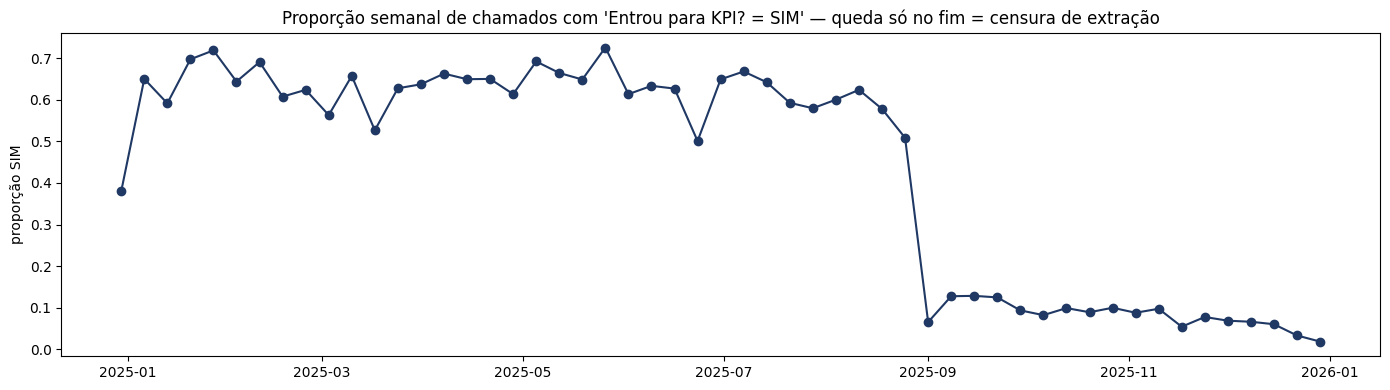

,semana,proporcao_elegivel,referencia,abaixo_do_limiar
0,2025-12-08/2025-12-14,0.0658,0.0992,True
1,2025-12-15/2025-12-21,0.0599,0.0992,True
2,2025-12-22/2025-12-28,0.0328,0.0992,True
3,2025-12-29/2026-01-04,0.0181,0.0992,True


2026-09-12 18:28:55 | WARNING  | sarimax_bottomup | CENSURA CONFIRMADA: 4 semana(s) finais com proporção elegível < 70% da referência (0.099). Treino de PRODUÇÃO passa a terminar em 2025-12-07.


In [11]:
prop_elegivel_semana = proporcao_elegivel_por_semana(df_risco, time_col='Aberto', flag_col='Entrou para KPI?')
print(prop_elegivel_semana.tail(12).round(3))

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(prop_elegivel_semana.index.to_timestamp(), prop_elegivel_semana.values, marker='o', color='#1F3864')
ax.set_title("Proporção semanal de chamados com 'Entrou para KPI? = SIM' — queda só no fim = censura de extração")
ax.set_ylabel('proporção SIM')
plt.tight_layout()
plt.show()

diag_censura = detectar_censura_elegibilidade(prop_elegivel_semana, semanas_referencia=20, semanas_finais_max=4, limiar_relativo=0.7)
display(diag_censura['detalhe'])

if diag_censura['censurado']:
    data_corte_producao = diag_censura['data_corte']
    logger.warning('CENSURA CONFIRMADA: %d semana(s) finais com proporção elegível < 70%% da referência (%.3f). '
                   'Treino de PRODUÇÃO passa a terminar em %s.',
                   diag_censura['n_semanas_censuradas'], diag_censura['referencia'], (data_corte_producao - pd.Timedelta(days=1)).date())
else:
    data_corte_producao = None
    logger.info('Sem evidência de censura: proporção elegível estável até o fim (referência %.3f). '
                'Treino de produção usa a série inteira; a queda de dezembro, se existir, é real.', diag_censura['referencia'])

---
## PARTE 1 — Folds walk-forward

In [12]:
folds = generate_expanding_folds(start_date='2025-01-01', min_train_weeks=30, test_weeks=7, n_folds=3)
for f in folds:
    logger.info(
        "Fold %d: treino %s a %s (%d dias) | teste %s a %s (%d dias)",
        f['fold'], f['train_start'].date(), f['train_end'].date(),
        (f['train_end'] - f['train_start']).days + 1,
        f['test_start'].date(), f['test_end'].date(),
        (f['test_end'] - f['test_start']).days + 1,
    )

2026-09-12 18:28:55 | INFO     | sarimax_bottomup | Fold 1: treino 2025-01-01 a 2025-07-29 (210 dias) | teste 2025-07-30 a 2025-09-16 (49 dias)


INFO:sarimax_bottomup:Fold 1: treino 2025-01-01 a 2025-07-29 (210 dias) | teste 2025-07-30 a 2025-09-16 (49 dias)


2026-09-12 18:28:55 | INFO     | sarimax_bottomup | Fold 2: treino 2025-01-01 a 2025-09-16 (259 dias) | teste 2025-09-17 a 2025-11-04 (49 dias)


INFO:sarimax_bottomup:Fold 2: treino 2025-01-01 a 2025-09-16 (259 dias) | teste 2025-09-17 a 2025-11-04 (49 dias)


2026-09-12 18:28:55 | INFO     | sarimax_bottomup | Fold 3: treino 2025-01-01 a 2025-11-04 (308 dias) | teste 2025-11-05 a 2025-12-23 (49 dias)


INFO:sarimax_bottomup:Fold 3: treino 2025-01-01 a 2025-11-04 (308 dias) | teste 2025-11-05 a 2025-12-23 (49 dias)


---
## PARTE 2 — Modelagem Bottom-Up: competição de variantes, por prioridade

Em vez de duplicar cada célula para P2 e para P3, o loop abaixo roda a **mesma competição de especificações** (`d=1`, `max_p=3`/`max_q=3`, BIC) para cada série, guardando os resultados num dicionário indexado por prioridade.

In [13]:
# com origem rolante (avaliar_por_horizonte, que trabalha sobre uma cópia do modelo).
nomes_variantes = ['sarima_classico', 'arimax_fourier', 'sarimax_hibrido']
HORIZONTES_OFICIAIS = (1, 7)


class _BaselineRolante:
    """Baselines com a mesma interface predict/update, para ter D+1/D+7 comparáveis:
    'naive' repete o último valor; 'seasonal' repete o valor de 7 dias antes."""
    def __init__(self, historico, modo):
        self.buffer = list(np.asarray(historico, dtype=float)[-7:])
        self.modo = modo
    def predict(self, n_periods, X=None):
        if self.modo == 'naive':
            return np.full(n_periods, self.buffer[-1])
        return np.array([self.buffer[(i) % 7] for i in range(n_periods)])
    def update(self, y, X=None):
        self.buffer = (self.buffer + list(np.asarray(y, dtype=float)))[-7:]


resultados_por_serie = {}
for nome_serie, serie in SERIES.items():
    logger.info('========== Série %s ==========', nome_serie)
    resultados_fold = []
    modelos_por_fold = {}

    for f in folds:
        treino_mask = (serie.index >= f['train_start']) & (serie.index <= f['train_end'])
        teste_mask = (serie.index >= f['test_start']) & (serie.index <= f['test_end'])
        serie_treino, serie_teste = serie[treino_mask], serie[teste_mask]
        exog_treino, exog_teste = exogenas[treino_mask], exogenas[teste_mask]

        previsoes = compute_all_baselines(serie_treino, len(serie_teste))
        metricas_horizonte = {
            'naive': avaliar_por_horizonte(_BaselineRolante(serie_treino, 'naive'), serie_teste, horizontes=HORIZONTES_OFICIAIS),
            'seasonal_naive': avaliar_por_horizonte(_BaselineRolante(serie_treino, 'seasonal'), serie_teste, horizontes=HORIZONTES_OFICIAIS),
        }

        modelos_por_fold[f['fold']] = {}
        for nome_variante in nomes_variantes:
            spec = SPECS_SARIMAX_PADRAO[nome_variante]
            info = rodar_variante_sarimax(nome_variante, spec, serie_treino, serie_teste, exog_treino, exog_teste)
            previsoes[nome_variante] = info['previsao']
            modelos_por_fold[f['fold']][nome_variante] = info
            assert info['ordem'][1] == 1, f'{nome_serie} fold {f["fold"]} [{nome_variante}]: d deveria ser 1!'
            X_h = exog_teste[spec['X_cols']] if spec['X_cols'] else None
            metricas_horizonte[nome_variante] = avaliar_por_horizonte(info['modelo'], serie_teste, X_h, horizontes=HORIZONTES_OFICIAIS)

        for nome_modelo, y_previsto in previsoes.items():
            m = calcular_metricas_serie(serie_teste.values, y_previsto)
            linha = {'serie': nome_serie, 'fold': f['fold'], 'modelo': nome_modelo, **{f'{k}_horizonte': v for k, v in m.items()}}
            linha.update(metricas_horizonte.get(nome_modelo, {}))
            resultados_fold.append(linha)

    resultados_por_serie[nome_serie] = {'resultados_fold': pd.DataFrame(resultados_fold), 'modelos_por_fold': modelos_por_fold}
    logger.info('%s: competição concluída nos 3 folds (bloco inteiro + D+1/D+7).', nome_serie)


2026-09-12 18:28:55 | INFO     | sarimax_bottomup | ========== Série P2 ==========


INFO:sarimax_bottomup:========== Série P2 ==========


2026-09-12 18:37:12 | INFO     | sarimax_bottomup | P2: competição concluída nos 3 folds (bloco inteiro + D+1/D+7).


INFO:sarimax_bottomup:P2: competição concluída nos 3 folds (bloco inteiro + D+1/D+7).


2026-09-12 18:37:12 | INFO     | sarimax_bottomup | ========== Série P3 ==========


INFO:sarimax_bottomup:========== Série P3 ==========


2026-09-12 18:47:30 | INFO     | sarimax_bottomup | P3: competição concluída nos 3 folds (bloco inteiro + D+1/D+7).


INFO:sarimax_bottomup:P3: competição concluída nos 3 folds (bloco inteiro + D+1/D+7).



## PARTE 3 — Comparação consolidada, por prioridade

**Pendência 7.** A tabela traz três leituras por modelo: MAE do bloco inteiro (49 dias, como antes), `MAE_D+1` e `MAE_D+7` com origem rolante — as duas últimas são o critério oficial da banca ("capacidade de antecipação em D+1 e D+7"). `CRITERIO_SELECAO` define qual coluna escolhe a variante vencedora; a recomendação do briefing é priorizar D+1/D+7 (aqui, a média das duas). Se o vencedor por esse critério for diferente do vencedor por bloco inteiro, o log avisa — é um achado a documentar, não a ignorar.


In [14]:
CRITERIO_SELECAO = 'MAE_D1_D7_medio'   # alternativas: 'MAE_horizonte' (bloco inteiro), 'MAE_D+1', 'MAE_D+7'

melhor_variante_por_serie = {}
vencedor_por_criterio = {}

for nome_serie in SERIES:
    df_resultados = resultados_por_serie[nome_serie]['resultados_fold'].copy()
    df_resultados['MAE_D1_D7_medio'] = df_resultados[['MAE_D+1', 'MAE_D+7']].mean(axis=1)
    colunas = ['MAE_horizonte', 'MedAE_horizonte', 'RMSE_horizonte', 'MAE_D+1', 'MAE_D+7', 'MAE_D1_D7_medio']
    resumo = df_resultados.groupby('modelo')[colunas].mean().round(2).sort_values(CRITERIO_SELECAO)

    so_variantes = resumo.loc[resumo.index.isin(nomes_variantes)]
    vencedor_por_criterio[nome_serie] = {crit: so_variantes[crit].idxmin() for crit in ['MAE_horizonte', 'MAE_D+1', 'MAE_D+7', 'MAE_D1_D7_medio']}
    melhor = vencedor_por_criterio[nome_serie][CRITERIO_SELECAO]
    melhor_variante_por_serie[nome_serie] = melhor

    if vencedor_por_criterio[nome_serie]['MAE_horizonte'] != melhor:
        logger.warning('%s: vencedor por %s = %s, mas por bloco inteiro seria %s — critérios divergem; documentar a escolha.',
                       nome_serie, CRITERIO_SELECAO, melhor, vencedor_por_criterio[nome_serie]['MAE_horizonte'])
    else:
        logger.info('%s: melhor variante = %s (mesmo vencedor por bloco inteiro e por D+1/D+7).', nome_serie, melhor)
    print(f'--- {nome_serie} ---  (critério de seleção: {CRITERIO_SELECAO})')
    display(resumo)


2026-09-12 18:47:30 | WARNING  | sarimax_bottomup | P2: vencedor por MAE_D1_D7_medio = sarima_classico, mas por bloco inteiro seria arimax_fourier — critérios divergem; documentar a escolha.


--- P2 ---  (critério de seleção: MAE_D1_D7_medio)


,MAE_horizonte,MedAE_horizonte,RMSE_horizonte,MAE_D+1,MAE_D+7,MAE_D1_D7_medio
modelo,,,,,,
sarima_classico,4.34,3.71,5.61,4.07,4.32,4.19
arimax_fourier,4.32,3.24,5.84,4.27,4.38,4.32
sarimax_hibrido,4.47,3.43,5.89,4.33,4.33,4.33
seasonal_naive,5.20,4.00,6.47,5.50,5.57,5.54
naive,4.87,4.00,6.11,5.55,5.57,5.56
arima_puro,4.56,3.89,5.74,NaN,NaN,NaN
rolling_mean_7d,4.73,4.33,6.14,NaN,NaN,NaN


2026-09-12 18:47:30 | WARNING  | sarimax_bottomup | P3: vencedor por MAE_D1_D7_medio = sarimax_hibrido, mas por bloco inteiro seria sarima_classico — critérios divergem; documentar a escolha.


--- P3 ---  (critério de seleção: MAE_D1_D7_medio)


,MAE_horizonte,MedAE_horizonte,RMSE_horizonte,MAE_D+1,MAE_D+7,MAE_D1_D7_medio
modelo,,,,,,
sarimax_hibrido,13.11,12.71,15.90,9.49,10.10,9.80
sarima_classico,11.87,9.71,14.69,9.14,10.70,9.92
arimax_fourier,12.07,11.23,14.74,10.28,10.34,10.31
seasonal_naive,11.90,9.33,14.83,11.52,11.57,11.55
naive,31.63,25.67,38.25,19.59,11.57,15.58
arima_puro,31.63,25.67,38.25,NaN,NaN,NaN
rolling_mean_7d,18.92,15.29,23.63,NaN,NaN,NaN


---
## PARTE 4 — Teste de parcimônia, por prioridade

Comparar a especificação vencedora completa contra a versão sem os termos de Fourier (`dow_sin`/`dow_cos`).

In [15]:
especificacao_final_por_serie = {}

for nome_serie, serie in SERIES.items():
    melhor = melhor_variante_por_serie[nome_serie]
    if melhor != 'arimax_fourier':
        # o teste de parcimônia (remover Fourier) só se aplica quando a variante vencedora usa Fourier
        especificacao_final_por_serie[nome_serie] = melhor
        logger.info('%s: melhor variante (%s) não usa Fourier — parcimônia não se aplica, mantendo como está.', nome_serie, melhor)
        continue

    resultados_parcimonia = []
    for f in folds:
        treino_mask = (serie.index >= f['train_start']) & (serie.index <= f['train_end'])
        teste_mask = (serie.index >= f['test_start']) & (serie.index <= f['test_end'])
        serie_treino, serie_teste = serie[treino_mask], serie[teste_mask]
        exog_treino, exog_teste = exogenas[treino_mask], exogenas[teste_mask]

        info_completo = resultados_por_serie[nome_serie]['modelos_por_fold'][f['fold']]['arimax_fourier']
        info_parcimonioso = rodar_variante_sarimax('arimax_fourier_parcimonioso', SPECS_SARIMAX_PADRAO['arimax_fourier_parcimonioso'], serie_treino, serie_teste, exog_treino, exog_teste)

        resultados_parcimonia.append({
            'fold': f['fold'],
            'BIC_completo': info_completo['bic'], 'BIC_parcimonioso': info_parcimonioso['bic'],
            'MAE_completo': calcular_metricas_serie(serie_teste.values, info_completo['previsao'])['MAE'],
            'MAE_parcimonioso': calcular_metricas_serie(serie_teste.values, info_parcimonioso['previsao'])['MAE'],
        })

    df_parcimonia = pd.DataFrame(resultados_parcimonia)
    df_parcimonia['BIC_favorece_parcimonioso'] = df_parcimonia['BIC_parcimonioso'] < df_parcimonia['BIC_completo']
    especificacao_final_por_serie[nome_serie] = 'arimax_fourier_parcimonioso' if df_parcimonia['BIC_favorece_parcimonioso'].mean() > 0.5 else 'arimax_fourier'
    logger.info('%s: especificação final = %s', nome_serie, especificacao_final_por_serie[nome_serie])
    print(f'--- {nome_serie} ---')
    display(df_parcimonia)


2026-09-12 18:47:30 | INFO     | sarimax_bottomup | P2: melhor variante (sarima_classico) não usa Fourier — parcimônia não se aplica, mantendo como está.


INFO:sarimax_bottomup:P2: melhor variante (sarima_classico) não usa Fourier — parcimônia não se aplica, mantendo como está.


2026-09-12 18:47:30 | INFO     | sarimax_bottomup | P3: melhor variante (sarimax_hibrido) não usa Fourier — parcimônia não se aplica, mantendo como está.


INFO:sarimax_bottomup:P3: melhor variante (sarimax_hibrido) não usa Fourier — parcimônia não se aplica, mantendo como está.


---
## PARTE 5 — Ensemble e escala, por prioridade

Ensemble com média móvel; escala bruta vs. `log1p` com correção de Duan — reaplicados a cada série, porque a conclusão de uma prioridade não pode ser assumida como válida pra outra sem testar.

In [16]:
usar_log_por_serie = {}

for nome_serie, serie in SERIES.items():
    spec_final = SPECS_SARIMAX_PADRAO[especificacao_final_por_serie[nome_serie]]
    f3 = folds[-1]
    treino_mask_f3 = (serie.index >= f3['train_start']) & (serie.index <= f3['train_end'])
    teste_mask_f3 = (serie.index >= f3['test_start']) & (serie.index <= f3['test_end'])
    serie_treino_f3, serie_teste_f3 = serie[treino_mask_f3], serie[teste_mask_f3]
    exog_treino_f3, exog_teste_f3 = exogenas[treino_mask_f3], exogenas[teste_mask_f3]

    # --- Ensemble (todos os 3 folds) ---
    resultados_ensemble = []
    for f in folds:
        treino_mask = (serie.index >= f['train_start']) & (serie.index <= f['train_end'])
        teste_mask = (serie.index >= f['test_start']) & (serie.index <= f['test_end'])
        serie_treino, serie_teste = serie[treino_mask], serie[teste_mask]

        if especificacao_final_por_serie[nome_serie] == melhor_variante_por_serie[nome_serie]:
            previsao_final = resultados_por_serie[nome_serie]['modelos_por_fold'][f['fold']][melhor_variante_por_serie[nome_serie]]['previsao']
        else:
            info = rodar_variante_sarimax(especificacao_final_por_serie[nome_serie], spec_final, serie_treino, serie_teste, exogenas[treino_mask], exogenas[teste_mask])
            previsao_final = info['previsao']

        previsao_rolling = baseline_rolling_mean(serie_treino, len(serie_teste))
        for peso in [1.0, 0.7, 0.5, 0.3, 0.0]:
            combinada = peso * previsao_final + (1 - peso) * previsao_rolling
            resultados_ensemble.append({'fold': f['fold'], 'peso_sarimax': peso, 'MAE': calcular_metricas_serie(serie_teste.values, combinada)['MAE']})

    df_ensemble = pd.DataFrame(resultados_ensemble)
    resumo_ensemble = df_ensemble.groupby('peso_sarimax')['MAE'].mean().round(2).sort_values()
    logger.info('%s: melhor peso do ensemble = %.1f (MAE %.2f)', nome_serie, resumo_ensemble.index[0], resumo_ensemble.iloc[0])

    # --- Escala bruta vs. log1p (todos os 3 folds, com correção de Duan) ---
    resultados_escala = []
    for f in folds:
        treino_mask = (serie.index >= f['train_start']) & (serie.index <= f['train_end'])
        teste_mask = (serie.index >= f['test_start']) & (serie.index <= f['test_end'])
        serie_treino, serie_teste = serie[treino_mask], serie[teste_mask]
        exog_treino, exog_teste = exogenas[treino_mask], exogenas[teste_mask]

        if especificacao_final_por_serie[nome_serie] in resultados_por_serie[nome_serie]['modelos_por_fold'][f['fold']]:
            mae_bruta = calcular_metricas_serie(serie_teste.values, resultados_por_serie[nome_serie]['modelos_por_fold'][f['fold']][especificacao_final_por_serie[nome_serie]]['previsao'])['MAE']
        else:
            info_bruta = rodar_variante_sarimax(especificacao_final_por_serie[nome_serie], spec_final, serie_treino, serie_teste, exog_treino, exog_teste)
            mae_bruta = calcular_metricas_serie(serie_teste.values, info_bruta['previsao'])['MAE']

        X_treino_log = exog_treino[spec_final['X_cols']] if spec_final['X_cols'] else None
        X_teste_log = exog_teste[spec_final['X_cols']] if spec_final['X_cols'] else None
        serie_log_treino = np.log1p(serie_treino)
        modelo_log = pm.auto_arima(
            serie_log_treino, X=X_treino_log, d=1, seasonal=spec_final['seasonal'], m=7 if spec_final['seasonal'] else 1,
            max_p=3, max_q=3, information_criterion='bic', stepwise=True, suppress_warnings=True, error_action='ignore',
        )
        prev_log, _ = modelo_log.predict(n_periods=len(serie_teste), X=X_teste_log, return_conf_int=True)
        residuos_log_treino = serie_log_treino.values - modelo_log.predict_in_sample(X=X_treino_log)
        prev_log_corrigida = log1p_bias_corrected_forecast(np.asarray(prev_log), residuos_log_treino)
        mae_log = calcular_metricas_serie(serie_teste.values, prev_log_corrigida)['MAE']

        resultados_escala.append({'fold': f['fold'], 'MAE_bruta': mae_bruta, 'MAE_log1p_corrigido': mae_log})

    df_escala = pd.DataFrame(resultados_escala)
    media_bruta, media_log = df_escala['MAE_bruta'].mean(), df_escala['MAE_log1p_corrigido'].mean()
    usar_log_por_serie[nome_serie] = media_log < media_bruta
    logger.info('%s: escala escolhida = %s (bruta=%.2f, log1p=%.2f)', nome_serie, 'log1p' if usar_log_por_serie[nome_serie] else 'bruta', media_bruta, media_log)

2026-09-12 18:47:30 | INFO     | sarimax_bottomup | P2: melhor peso do ensemble = 0.7 (MAE 4.32)


INFO:sarimax_bottomup:P2: melhor peso do ensemble = 0.7 (MAE 4.32)


2026-09-12 18:48:55 | INFO     | sarimax_bottomup | P2: escala escolhida = bruta (bruta=4.34, log1p=4.99)


INFO:sarimax_bottomup:P2: escala escolhida = bruta (bruta=4.34, log1p=4.99)


2026-09-12 18:48:56 | INFO     | sarimax_bottomup | P3: melhor peso do ensemble = 0.7 (MAE 12.84)


INFO:sarimax_bottomup:P3: melhor peso do ensemble = 0.7 (MAE 12.84)


2026-09-12 18:53:55 | INFO     | sarimax_bottomup | P3: escala escolhida = log1p (bruta=13.11, log1p=12.41)


INFO:sarimax_bottomup:P3: escala escolhida = log1p (bruta=13.11, log1p=12.41)


---
## PARTE 7 — Visualização — fold 3, especificação final, por prioridade

/tmp/ipykernel_7873/252271580.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(serie_teste_f3.index, info_f3['previsao'], label=f'Previsto ({spec_final})', color='#c0392b', marker='x')
/tmp/ipykernel_7873/252271580.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(serie_teste_f3.index, info_f3['previsao'], label=f'Previsto ({spec_final})', color='#c0392b', marker='x')


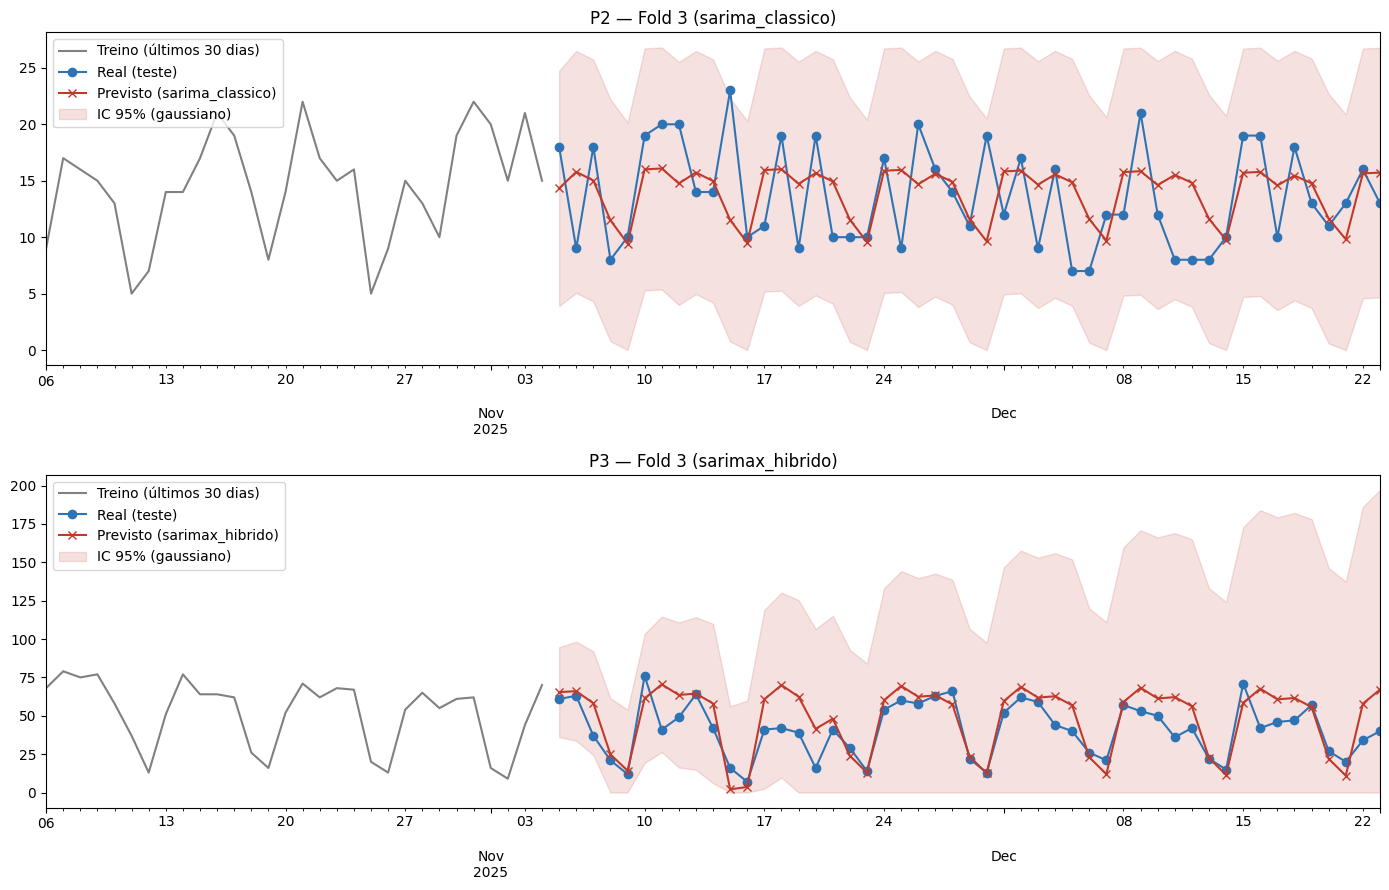

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

for ax, nome_serie in zip(axes, SERIES):
    serie = SERIES[nome_serie]
    f3 = folds[-1]
    treino_mask_f3 = (serie.index >= f3['train_start']) & (serie.index <= f3['train_end'])
    teste_mask_f3 = (serie.index >= f3['test_start']) & (serie.index <= f3['test_end'])
    serie_treino_f3, serie_teste_f3 = serie[treino_mask_f3], serie[teste_mask_f3]

    spec_final = especificacao_final_por_serie[nome_serie]
    info_f3 = resultados_por_serie[nome_serie]['modelos_por_fold'][3].get(spec_final)
    if info_f3 is None:
        info_f3 = rodar_variante_sarimax(spec_final, SPECS_SARIMAX_PADRAO[spec_final], serie_treino_f3, serie_teste_f3, exogenas[treino_mask_f3], exogenas[teste_mask_f3])

    serie_treino_f3.iloc[-30:].plot(ax=ax, label='Treino (últimos 30 dias)', color='grey')
    serie_teste_f3.plot(ax=ax, label='Real (teste)', color='#2E74B5', marker='o')
    ax.plot(serie_teste_f3.index, info_f3['previsao'], label=f'Previsto ({spec_final})', color='#c0392b', marker='x')
    ax.fill_between(serie_teste_f3.index, info_f3['ic'][:, 0], info_f3['ic'][:, 1], color='#c0392b', alpha=0.15, label='IC 95% (gaussiano)')
    ax.legend()
    ax.set_title(f'{nome_serie} — Fold 3 ({spec_final})')

plt.tight_layout()
plt.show()

---
## PARTE 8 — Modelo de produção — P2, P3, e a soma Bottom-Up

In [18]:
modelos_producao = {}
previsoes_producao = {}
SERIES_PRODUCAO = {}

for nome_serie, serie in SERIES.items():
    serie_prod = serie[serie.index < data_corte_producao] if data_corte_producao is not None else serie
    SERIES_PRODUCAO[nome_serie] = serie_prod
    exog_prod = exogenas.loc[serie_prod.index]

    spec_final = SPECS_SARIMAX_PADRAO[especificacao_final_por_serie[nome_serie]]
    X_producao = exog_prod[spec_final['X_cols']] if spec_final['X_cols'] else None
    usar_log = usar_log_por_serie[nome_serie]
    serie_para_treino = np.log1p(serie_prod) if usar_log else serie_prod

    modelo_producao = pm.auto_arima(
        serie_para_treino, X=X_producao, d=1, seasonal=spec_final['seasonal'], m=7 if spec_final['seasonal'] else 1,
        max_p=3, max_q=3, information_criterion='bic', stepwise=True, suppress_warnings=True, error_action='ignore',
    )
    assert modelo_producao.order[1] == 1
    modelos_producao[nome_serie] = {'modelo': modelo_producao, 'usar_log': usar_log, 'spec': spec_final}
    logger.info('%s: modelo de produção = %s%sx%s | escala=%s | treinado até %s (%d dias)',
                nome_serie, especificacao_final_por_serie[nome_serie], modelo_producao.order, modelo_producao.seasonal_order,
                'log1p' if usar_log else 'bruta', serie_prod.index.max().date(), len(serie_prod))


2026-09-12 18:54:38 | INFO     | sarimax_bottomup | P2: modelo de produção = sarima_classico(1, 1, 1)x(0, 0, 2, 7) | escala=bruta | treinado até 2025-12-07 (341 dias)


INFO:sarimax_bottomup:P2: modelo de produção = sarima_classico(1, 1, 1)x(0, 0, 2, 7) | escala=bruta | treinado até 2025-12-07 (341 dias)


2026-09-12 18:56:03 | INFO     | sarimax_bottomup | P3: modelo de produção = sarimax_hibrido(3, 1, 0)x(1, 0, 1, 7) | escala=log1p | treinado até 2025-12-07 (341 dias)


INFO:sarimax_bottomup:P3: modelo de produção = sarimax_hibrido(3, 1, 0)x(1, 0, 1, 7) | escala=log1p | treinado até 2025-12-07 (341 dias)


In [19]:
ultimo_dia_treino = SERIES_PRODUCAO['P2'].index.max()
datas_futuras = pd.date_range(ultimo_dia_treino + pd.Timedelta(days=1), periods=7, freq='D')
logger.info('Horizonte de produção: %s a %s', datas_futuras[0].date(), datas_futuras[-1].date())

for nome_serie in SERIES:
    info = modelos_producao[nome_serie]
    exog_futuro = construir_exogenas_futuras(datas_futuras[0].strftime('%Y-%m-%d'), 7, colunas=info['spec']['X_cols'])
    previsao, ic = info['modelo'].predict(n_periods=7, X=exog_futuro, return_conf_int=True)
    previsao = np.asarray(previsao)

    if info['usar_log']:
        residuos_treino = np.asarray(info['modelo'].arima_res_.resid)
        previsao_final = log1p_bias_corrected_forecast(previsao, residuos_treino)
        ic_final = np.expm1(ic)
    else:
        previsao_final = previsao
        ic_final = ic

    previsao_final = np.maximum(previsao_final, 0)
    ic_final[:, 0] = np.maximum(ic_final[:, 0], 0)

    previsoes_producao[nome_serie] = pd.DataFrame({
        'data': datas_futuras,
        f'previsao_{nome_serie.lower()}': np.round(previsao_final).astype(int),
        f'ic_inferior_{nome_serie.lower()}': np.round(ic_final[:, 0]).astype(int),
        f'ic_superior_{nome_serie.lower()}': np.round(ic_final[:, 1]).astype(int),
    })

df_previsao_total = previsoes_producao['P2'].merge(previsoes_producao['P3'], on='data')
df_previsao_total['previsao_total_p2_p3'] = df_previsao_total['previsao_p2'] + df_previsao_total['previsao_p3']
df_previsao_total['ic_inferior_total'] = df_previsao_total['ic_inferior_p2'] + df_previsao_total['ic_inferior_p3']
df_previsao_total['ic_superior_total'] = df_previsao_total['ic_superior_p2'] + df_previsao_total['ic_superior_p3']

df_previsao_total

2026-09-12 18:56:03 | INFO     | sarimax_bottomup | Horizonte de produção: 2025-12-08 a 2025-12-14


INFO:sarimax_bottomup:Horizonte de produção: 2025-12-08 a 2025-12-14


,data,previsao_p2,ic_inferior_p2,ic_superior_p2,previsao_p3,ic_inferior_p3,ic_superior_p3,previsao_total_p2_p3,ic_inferior_total,ic_superior_total
0,2025-12-08,14,3,25,63,33,103,77,36,128
1,2025-12-09,13,2,24,67,34,115,80,36,139
2,2025-12-10,15,3,26,70,35,124,85,38,150
3,2025-12-11,14,3,25,71,33,132,85,36,157
4,2025-12-12,13,2,24,62,27,123,75,29,147
5,2025-12-13,12,1,23,31,13,64,43,14,87
6,2025-12-14,15,4,26,17,6,37,32,10,63


**Nota sobre o intervalo de confiança da soma:** somar os limites inferior/superior dos dois ICs (em vez de recalcular a incerteza combinada) é uma aproximação conservadora — assume que os erros de P2 e P3 são perfeitamente correlacionados positivamente, o que tende a produzir um intervalo mais largo do que a incerteza real combinada (se os erros forem parcialmente independentes, o intervalo verdadeiro seria mais estreito). Preferimos errar para um IC mais largo do que subestimar a incerteza da soma.

### 8.1 Coeficientes e diagnóstico formal de resíduos, por prioridade

In [20]:
diagnosticos_producao = {}

for nome_serie in SERIES:
    print(f'========== {nome_serie} ==========')
    print(modelos_producao[nome_serie]['modelo'].summary())
    print()

    diagnostico = diagnostico_residuos(modelos_producao[nome_serie]['modelo'])
    diagnosticos_producao[nome_serie] = diagnostico
    for chave, valor in diagnostico.items():
        logger.info('%s | %s: %s', nome_serie, chave, valor)

    if diagnostico['breusch_pagan_p'] < 0.05:
        logger.warning('%s: Breusch-Pagan confirma heterocedasticidade (p=%.4f) — usar o IC por bootstrap abaixo como referência.', nome_serie, diagnostico['breusch_pagan_p'])
    print()

========== P2 ==========
                                       SARIMAX Results                                        
Dep. Variable:                                      y   No. Observations:                  341
Model:             SARIMAX(1, 1, 1)x(0, 0, [1, 2], 7)   Log Likelihood               -1062.384
Date:                                Sat, 12 Sep 2026   AIC                           2134.768
Time:                                        18:56:04   BIC                           2153.912
Sample:                                    01-01-2025   HQIC                          2142.396
                                         - 12-07-2025                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2505      0.045      5.549      0.000   

INFO:sarimax_bottomup:P2 | ljung_box_p: 0.765


2026-09-12 18:56:04 | INFO     | sarimax_bottomup | P2 | jarque_bera_stat: 83.3


INFO:sarimax_bottomup:P2 | jarque_bera_stat: 83.3


2026-09-12 18:56:04 | INFO     | sarimax_bottomup | P2 | jarque_bera_p: 0.0


...

2026-09-12 18:56:04 | INFO     | sarimax_bottomup | P3 | breusch_pagan_stat: 70.07


INFO:sarimax_bottomup:P3 | breusch_pagan_stat: 70.07


2026-09-12 18:56:04 | INFO     | sarimax_bottomup | P3 | breusch_pagan_p: 0.0


INFO:sarimax_bottomup:P3 | breusch_pagan_p: 0.0


2026-09-12 18:56:04 | WARNING  | sarimax_bottomup | P3: Breusch-Pagan confirma heterocedasticidade (p=0.0000) — usar o IC por bootstrap abaixo como referência.



### 8.2 Intervalo de previsão por bootstrap dos resíduos — conjunto P2+P3

Somar os limites de P2 e P3 assumia erros perfeitamente correlacionados e produzia um IC 90% de W+1 de [23, 464], inútil para decisão. Agora o bootstrap sorteia o **mesmo dia** para as duas séries em cada reamostragem, soma as trajetórias e tira os percentis da distribuição da **soma** — preserva a correlação real entre os resíduos. Os ICs por série continuam saindo do mesmo sorteio.


In [21]:
residuos_prod = {}
previsao_prod = {}
for nome_serie in SERIES:
    info = modelos_producao[nome_serie]
    residuos_prod[nome_serie] = np.asarray(info['modelo'].arima_res_.resid)
    previsao_prod[nome_serie] = previsoes_producao[nome_serie][f'previsao_{nome_serie.lower()}'].values.astype(float)

if any(modelos_producao[s]['usar_log'] for s in SERIES):
    # resíduos em log1p não são somáveis com resíduos em escala bruta — o bootstrap conjunto exige escala comum.
    # Cai para o método antigo (IC por série + soma dos limites, conservador) e avisa.
    logger.warning('Alguma série ficou em log1p: IC conjunto indisponível, usando IC por série + soma dos limites (conservador).')
    ic_conjunto = {}
    for nome_serie in SERIES:
        info = modelos_producao[nome_serie]
        res_log = residuos_prod[nome_serie]
        prev = previsao_prod[nome_serie]
        ic_b = bootstrap_prediction_interval(res_log, np.log1p(prev) if info['usar_log'] else prev, ci=0.90)
        if info['usar_log']:
            ic_b = {'ic_inferior': log1p_bias_corrected_forecast(ic_b['ic_inferior'], res_log), 'ic_superior': log1p_bias_corrected_forecast(ic_b['ic_superior'], res_log)}
        ic_conjunto[nome_serie] = {'ic_inferior': np.maximum(ic_b['ic_inferior'], 0), 'ic_superior': ic_b['ic_superior']}
    ic_conjunto['total'] = {
        'ic_inferior': sum(ic_conjunto[s]['ic_inferior'] for s in SERIES), 'ic_superior': sum(ic_conjunto[s]['ic_superior'] for s in SERIES),
        'w_inferior': float(sum(ic_conjunto[s]['ic_inferior'].sum() for s in SERIES)), 'w_superior': float(sum(ic_conjunto[s]['ic_superior'].sum() for s in SERIES)),
    }
else:
    ic_conjunto = bootstrap_prediction_interval_conjunto(residuos_prod, previsao_prod, n_boot=2000, ci=0.90)

for nome_serie in SERIES:
    previsoes_producao[nome_serie][f'ic_inferior_bootstrap_{nome_serie.lower()}'] = np.round(ic_conjunto[nome_serie]['ic_inferior']).astype(int)
    previsoes_producao[nome_serie][f'ic_superior_bootstrap_{nome_serie.lower()}'] = np.round(ic_conjunto[nome_serie]['ic_superior']).astype(int)

df_previsao_total['ic_inferior_bootstrap_total'] = np.round(ic_conjunto['total']['ic_inferior']).astype(int)
df_previsao_total['ic_superior_bootstrap_total'] = np.round(ic_conjunto['total']['ic_superior']).astype(int)

# comparação didática: IC da soma pela soma dos limites (antigo) vs. pela distribuição da soma (novo)
w1_ic_soma_limites = (int(previsoes_producao['P2']['ic_inferior_bootstrap_p2'].sum() + previsoes_producao['P3']['ic_inferior_bootstrap_p3'].sum()),
                      int(previsoes_producao['P2']['ic_superior_bootstrap_p2'].sum() + previsoes_producao['P3']['ic_superior_bootstrap_p3'].sum()))
w1_ic_conjunto = (int(round(ic_conjunto['total']['w_inferior'])), int(round(ic_conjunto['total']['w_superior'])))
logger.info('IC 90%% de W+1 — soma dos limites (antigo): [%d, %d] | distribuição da soma (novo): [%d, %d]',
            *w1_ic_soma_limites, *w1_ic_conjunto)

df_previsao_total[['data', 'previsao_p2', 'previsao_p3', 'previsao_total_p2_p3', 'ic_inferior_bootstrap_total', 'ic_superior_bootstrap_total']]


2026-09-12 18:56:04 | WARNING  | sarimax_bottomup | Alguma série ficou em log1p: IC conjunto indisponível, usando IC por série + soma dos limites (conservador).


2026-09-12 18:56:04 | INFO     | sarimax_bottomup | IC 90% de W+1 — soma dos limites (antigo): [271, 788] | distribuição da soma (novo): [273, 788]


INFO:sarimax_bottomup:IC 90% de W+1 — soma dos limites (antigo): [271, 788] | distribuição da soma (novo): [273, 788]


,data,previsao_p2,previsao_p3,previsao_total_p2_p3,ic_inferior_bootstrap_total,ic_superior_bootstrap_total
0,2025-12-08,14,63,77,46,126
1,2025-12-09,13,67,80,43,141
2,2025-12-10,15,70,85,50,137
3,2025-12-11,14,71,85,50,137
4,2025-12-12,13,62,75,44,123
5,2025-12-13,12,31,43,23,72
6,2025-12-14,15,17,32,18,52


### 8.3 Visão consolidada — P2 + P3

A análise técnica é sempre separada (P2 e P3 têm dinâmicas diferentes, tratadas como tal do início ao fim) — mas a decisão de negócio ("quantos chamados a operação deve esperar amanhã e na próxima semana") é sobre o total. Esta seção existe só para apresentar isso de forma direta, sem reabrir nenhuma decisão de modelagem.

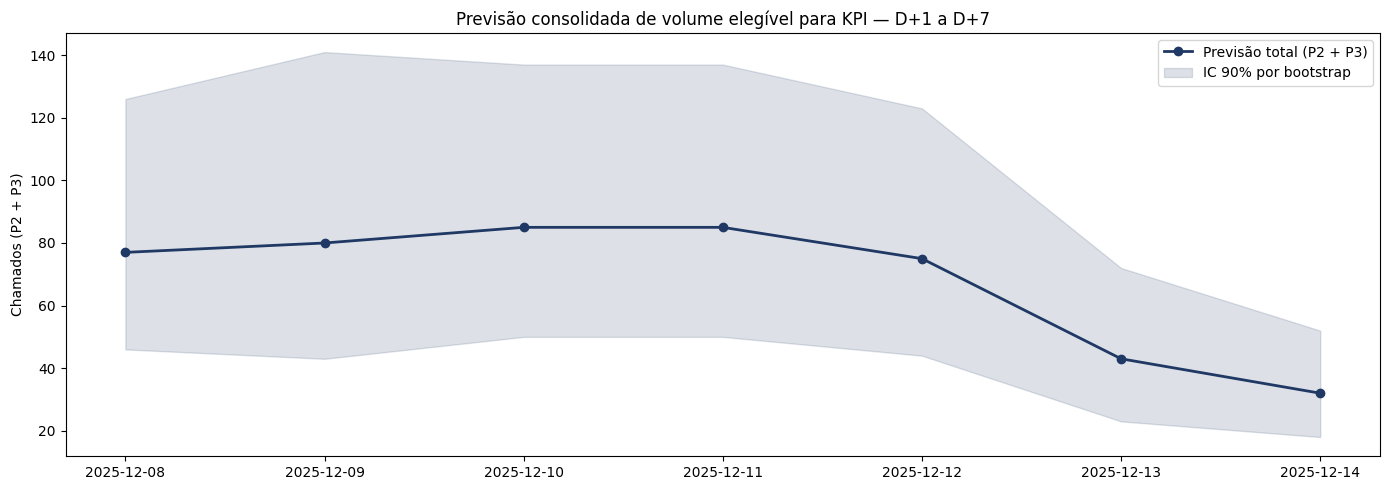

2026-09-12 18:56:05 | INFO     | sarimax_bottomup | W+1 consolidado (P2+P3): 477 chamados [273, 788] (IC 90% bootstrap)


INFO:sarimax_bottomup:W+1 consolidado (P2+P3): 477 chamados [273, 788] (IC 90% bootstrap)


2026-09-12 18:56:05 | INFO     | sarimax_bottomup | Previsão semanal (96.0) dentro de ±50% da média recente (101.5).


INFO:sarimax_bottomup:Previsão semanal (96.0) dentro de ±50% da média recente (101.5).


2026-09-12 18:56:05 | INFO     | sarimax_bottomup | Previsão semanal (381.0) dentro de ±50% da média recente (312.5).


INFO:sarimax_bottomup:Previsão semanal (381.0) dentro de ±50% da média recente (312.5).


2026-09-12 18:56:05 | INFO     | sarimax_bottomup | Previsão semanal (477.0) dentro de ±50% da média recente (414.0).


INFO:sarimax_bottomup:Previsão semanal (477.0) dentro de ±50% da média recente (414.0).


,previsao_semanal,media_recente,desvio_pct,dentro_do_esperado
P2,96.0,101.5,-5.4,True
P3,381.0,312.5,21.9,True
total,477.0,414.0,15.2,True


,métrica,valor
0,Previsão D+1 (total),77
1,Previsão W+1 (soma dos 7 dias),477
2,IC inferior W+1,273
3,IC superior W+1,788


In [22]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_previsao_total['data'], df_previsao_total['previsao_total_p2_p3'], marker='o', color='#1F3864', linewidth=2, label='Previsão total (P2 + P3)')
ax.fill_between(
    df_previsao_total['data'], df_previsao_total['ic_inferior_bootstrap_total'], df_previsao_total['ic_superior_bootstrap_total'],
    color='#1F3864', alpha=0.15, label='IC 90% por bootstrap',
)
ax.set_title('Previsão consolidada de volume elegível para KPI — D+1 a D+7')
ax.set_ylabel('Chamados (P2 + P3)')
ax.legend()
plt.tight_layout()
plt.show()

w1_total = int(df_previsao_total['previsao_total_p2_p3'].sum())
w1_ic_inferior, w1_ic_superior = w1_ic_conjunto

logger.info('W+1 consolidado (P2+P3): %d chamados [%d, %d] (IC 90%% bootstrap)', w1_total, w1_ic_inferior, w1_ic_superior)

guardrails_producao = {
    nome: validar_previsao_producao(float(previsoes_producao[nome][f'previsao_{nome.lower()}'].sum()), SERIES_PRODUCAO[nome], limite_desvio_pct=50, logger=logger)
    for nome in SERIES
}
guardrails_producao['total'] = validar_previsao_producao(float(w1_total), SERIES_PRODUCAO['P2'] + SERIES_PRODUCAO['P3'], limite_desvio_pct=50, logger=logger)
display(pd.DataFrame(guardrails_producao).T)
if not all(g['dentro_do_esperado'] for g in guardrails_producao.values()):
    logger.warning('Pelo menos uma previsão está fora de ±50%% da média recente — NÃO publicar no dashboard sem investigar.')

resumo_consolidado = pd.DataFrame({
    'métrica': ['Previsão D+1 (total)', 'Previsão W+1 (soma dos 7 dias)', 'IC inferior W+1', 'IC superior W+1'],
    'valor': [
        int(df_previsao_total['previsao_total_p2_p3'].iloc[0]),
        w1_total, w1_ic_inferior, w1_ic_superior,
    ],
})
resumo_consolidado

---
## PARTE 9 — Teto Contratual — comparação com as metas oficiais (Dicionário de Dados v2)

Dois comparativos, propositalmente separados:
1. **Atingimento real de 2025** — o volume elegível que já fechou no ano, direto da série histórica (sem projeção nenhuma).
2. **Projeção 2026** — extrapolação simples do ritmo do D+7 (soma semanal × 52) contra a mesma meta. É uma extrapolação ingênua, não uma previsão do ano inteiro — dito isso explicitamente, para não passar mais confiança do que ela tem.

In [23]:
print('=== 1. Atingimento REAL de 2025 (sem projeção) ===')
volume_real_2025_p2 = int(serie_p2.sum())
volume_real_2025_p3 = int(serie_p3.sum())
pct_real_p2 = checar_faixa_kpi(volume_real_2025_p2, FAIXAS_VOLUME_ANUAL_P2)
pct_real_p3 = checar_faixa_kpi(volume_real_2025_p3, FAIXAS_VOLUME_ANUAL_P3)
logger.info('P2 2025: volume elegível = %d -> %s%% de atingimento da meta anual', volume_real_2025_p2, pct_real_p2)
logger.info('P3 2025: volume elegível = %d -> %s%% de atingimento da meta anual', volume_real_2025_p3, pct_real_p3)

print()
print('=== 2. Projeção 2026 (extrapolação ingênua do ritmo do D+7) ===')
projecao_anual_p2 = int(df_previsao_total['previsao_p2'].sum() * 52)
projecao_anual_p3 = int(df_previsao_total['previsao_p3'].sum() * 52)
pct_projetado_p2 = checar_faixa_kpi(projecao_anual_p2, FAIXAS_VOLUME_ANUAL_P2)
pct_projetado_p3 = checar_faixa_kpi(projecao_anual_p3, FAIXAS_VOLUME_ANUAL_P3)
logger.info('P2: se o ritmo da semana prevista se mantivesse o ano todo -> %d/ano -> %s%% de atingimento', projecao_anual_p2, pct_projetado_p2)
logger.info('P3: se o ritmo da semana prevista se mantivesse o ano todo -> %d/ano -> %s%% de atingimento', projecao_anual_p3, pct_projetado_p3)

resumo_teto_contratual = pd.DataFrame({
    'prioridade': ['P2', 'P3'],
    'volume_real_2025': [volume_real_2025_p2, volume_real_2025_p3],
    'pct_atingimento_2025': [pct_real_p2, pct_real_p3],
    'projecao_anualizada_2026': [projecao_anual_p2, projecao_anual_p3],
    'pct_atingimento_projetado_2026': [pct_projetado_p2, pct_projetado_p3],
})
resumo_teto_contratual


=== 1. Atingimento REAL de 2025 (sem projeção) ===
2026-09-12 18:56:05 | INFO     | sarimax_bottomup | P2 2025: volume elegível = 5159 -> 125% de atingimento da meta anual


INFO:sarimax_bottomup:P2 2025: volume elegível = 5159 -> 125% de atingimento da meta anual


2026-09-12 18:56:05 | INFO     | sarimax_bottomup | P3 2025: volume elegível = 19997 -> 125% de atingimento da meta anual


INFO:sarimax_bottomup:P3 2025: volume elegível = 19997 -> 125% de atingimento da meta anual



=== 2. Projeção 2026 (extrapolação ingênua do ritmo do D+7) ===
2026-09-12 18:56:05 | INFO     | sarimax_bottomup | P2: se o ritmo da semana prevista se mantivesse o ano todo -> 4992/ano -> 125% de atingimento


INFO:sarimax_bottomup:P2: se o ritmo da semana prevista se mantivesse o ano todo -> 4992/ano -> 125% de atingimento


2026-09-12 18:56:05 | INFO     | sarimax_bottomup | P3: se o ritmo da semana prevista se mantivesse o ano todo -> 19812/ano -> 125% de atingimento


INFO:sarimax_bottomup:P3: se o ritmo da semana prevista se mantivesse o ano todo -> 19812/ano -> 125% de atingimento


,prioridade,volume_real_2025,pct_atingimento_2025,projecao_anualizada_2026,pct_atingimento_projetado_2026
0,P2,5159,125,4992,125
1,P3,19997,125,19812,125


**Como ler:** a projeção 2026 é sensível ao dia da semana em que ela é calculada (7 dias específicos, não uma média do ano) — não é uma previsão de atingimento anual robusta, é uma leitura rápida de "estamos no mesmo patamar do ano passado, ou o ritmo mudou?". Para uma projeção anual de verdade, seria preciso rodar o modelo em cascata ao longo do ano (re-treinar a cada novo trecho de dado real) — fora do escopo desta entrega, mas registrado aqui como próximo passo natural.

## PARTE 9b — Projeção de perda de OLA para D+1 a D+7

O objetivo oficial "projetar impacto nos KPIs" pede tendência de volume **e de perda de OLA**. Aproximação deliberadamente simples e transparente: violações esperadas por dia = volume previsto por prioridade × taxa histórica de violação por prioridade (últimas 8 semanas não censuradas). Supõe taxa estável no horizonte — premissa declarada, não escondida.

**Validação antes de confiar:** a mesma multiplicação é aplicada ao fold 3 (volume previsto pelo modelo do fold × taxa calculada só no treino do fold) e comparada com as violações **reais** do período de teste. Se errar muito ali, a projeção de produção não merece confiança.

In [24]:
df_elegivel['target'] = (df_elegivel['KPI Violado?'] == 'SIM').astype(int)
MAPA_PRIORIDADE = {'P2': '2 - Alta', 'P3': '3 - Média'}

# --- validação no fold 3 ---
f3 = folds[-1]
df_treino_f3_ola = df_elegivel[(df_elegivel['Aberto'] >= f3['train_start']) & (df_elegivel['Aberto'] <= f3['train_end'])]
df_teste_f3_ola = df_elegivel[(df_elegivel['Aberto'] >= f3['test_start']) & (df_elegivel['Aberto'] <= f3['test_end'])]
taxa_f3 = taxa_violacao_historica_por_prioridade(df_treino_f3_ola, time_col='Aberto', semanas_recentes=8)

prev_vol_f3 = {}
for nome_serie in SERIES:
    spec_nome = especificacao_final_por_serie[nome_serie]
    info_f3 = resultados_por_serie[nome_serie]['modelos_por_fold'][3].get(spec_nome)
    if info_f3 is None:
        serie = SERIES[nome_serie]
        tm = (serie.index >= f3['train_start']) & (serie.index <= f3['train_end'])
        te = (serie.index >= f3['test_start']) & (serie.index <= f3['test_end'])
        info_f3 = rodar_variante_sarimax(spec_nome, SPECS_SARIMAX_PADRAO[spec_nome], serie[tm], serie[te], exogenas[tm], exogenas[te])
    prev_vol_f3[nome_serie] = info_f3['previsao']

ola_f3 = projetar_ola_esperado(prev_vol_f3, {k: taxa_f3[MAPA_PRIORIDADE[k]] for k in SERIES})
validacao_ola = pd.DataFrame({
    'prioridade': list(SERIES) + ['total'],
    'violacoes_reais_teste_f3': [int(df_teste_f3_ola.loc[df_teste_f3_ola['Prioridade'] == MAPA_PRIORIDADE[k], 'target'].sum()) for k in SERIES] + [int(df_teste_f3_ola['target'].sum())],
    'violacoes_projetadas_teste_f3': [round(ola_f3[f'ola_esperado_{k}'].sum(), 1) for k in SERIES] + [round(ola_f3['ola_esperado_total'].sum(), 1)],
})
validacao_ola['erro_abs'] = (validacao_ola['violacoes_reais_teste_f3'] - validacao_ola['violacoes_projetadas_teste_f3']).abs().round(1)
print('=== Validação da projeção de OLA no fold 3 (49 dias de teste) ===')
display(validacao_ola)

# --- projeção de produção D+1..D+7 ---
df_elegivel_prod = df_elegivel if data_corte_producao is None else df_elegivel[df_elegivel['Aberto'] < data_corte_producao]
taxa_prod = taxa_violacao_historica_por_prioridade(df_elegivel_prod, time_col='Aberto', semanas_recentes=8)
logger.info('Taxa de violação (últimas 8 semanas não censuradas): %s', taxa_prod.round(4).to_dict())

ola_producao = projetar_ola_esperado(
    {k: previsoes_producao[k][f'previsao_{k.lower()}'].values for k in SERIES},
    {k: taxa_prod[MAPA_PRIORIDADE[k]] for k in SERIES},
    ic_inferior_por_prioridade={k: previsoes_producao[k][f'ic_inferior_bootstrap_{k.lower()}'].values for k in SERIES},
    ic_superior_por_prioridade={k: previsoes_producao[k][f'ic_superior_bootstrap_{k.lower()}'].values for k in SERIES},
)
ola_producao.insert(0, 'data', datas_futuras)
display(ola_producao)

w1_ola_esperado = float(ola_producao['ola_esperado_total'].sum())
logger.info('Perda de OLA esperada em W+1: %.1f violações (P2 %.1f | P3 %.1f) — cenário pessimista %.1f',
            w1_ola_esperado, ola_producao['ola_esperado_P2'].sum(), ola_producao['ola_esperado_P3'].sum(), ola_producao['ola_esperado_total_ic_sup'].sum())

# leitura contra a meta anual oficial (extrapolação ingênua, mesma ressalva da Parte 9)
for k, faixas in [('P2', FAIXAS_OLA_QUEBRADO_ANUAL_P2), ('P3', FAIXAS_OLA_QUEBRADO_ANUAL_P3)]:
    proj_anual = ola_producao[f'ola_esperado_{k}'].sum() * 52
    logger.info('%s: se o ritmo de OLA quebrado de W+1 se mantivesse -> %.0f/ano -> %s%% de atingimento da meta oficial', k, proj_anual, checar_faixa_kpi(proj_anual, faixas))

(PROJECT_PATHS.gold / 'exports_dashboard').mkdir(parents=True, exist_ok=True)
ola_producao.to_csv(PROJECT_PATHS.gold / 'exports_dashboard' / 'projecao_ola_d1_d7.csv', index=False, encoding='utf-8-sig')

df_previsao_total[[
    'data', 'previsao_p2', 'previsao_p3', 'previsao_total_p2_p3',
    'ic_inferior_bootstrap_total', 'ic_superior_bootstrap_total',
]].to_csv(PROJECT_PATHS.gold / 'exports_dashboard' / 'previsao_volume_d1_d7.csv', index=False, encoding='utf-8-sig')
logger.info('Previsão de volume D+1/D+7 exportada: %s', PROJECT_PATHS.gold / 'exports_dashboard' / 'previsao_volume_d1_d7.csv')

=== Validação da projeção de OLA no fold 3 (49 dias de teste) ===


,prioridade,violacoes_reais_teste_f3,violacoes_projetadas_teste_f3,erro_abs
0,P2,6,3.2,2.8
1,P3,28,12.5,15.5
2,total,34,15.7,18.3


2026-09-12 18:56:05 | INFO     | sarimax_bottomup | Taxa de violação (últimas 8 semanas não censuradas): {'2 - Alta': 0.0099, '3 - Média': 0.0104}


INFO:sarimax_bottomup:Taxa de violação (últimas 8 semanas não censuradas): {'2 - Alta': 0.0099, '3 - Média': 0.0104}


,data,ola_esperado_P2,ola_esperado_P2_ic_inf,ola_esperado_P2_ic_sup,ola_esperado_P3,ola_esperado_P3_ic_inf,ola_esperado_P3_ic_sup,ola_esperado_total,ola_esperado_total_ic_inf,ola_esperado_total_ic_sup
0,2025-12-08,0.138,0.059,0.227,0.655,0.416,1.071,0.793,0.475,1.298
1,2025-12-09,0.128,0.049,0.207,0.697,0.395,1.248,0.825,0.444,1.455
2,2025-12-10,0.148,0.069,0.236,0.728,0.447,1.175,0.876,0.516,1.412
3,2025-12-11,0.138,0.059,0.217,0.738,0.447,1.196,0.876,0.506,1.413
4,2025-12-12,0.128,0.049,0.207,0.645,0.395,1.061,0.773,0.444,1.268
5,2025-12-13,0.118,0.039,0.197,0.322,0.198,0.541,0.441,0.237,0.738
6,2025-12-14,0.148,0.069,0.236,0.177,0.104,0.291,0.325,0.173,0.528


...

INFO:sarimax_bottomup:P2: se o ritmo de OLA quebrado de W+1 se mantivesse -> 49/ano -> 50% de atingimento da meta oficial


2026-09-12 18:56:05 | INFO     | sarimax_bottomup | P3: se o ritmo de OLA quebrado de W+1 se mantivesse -> 206/ano -> 125% de atingimento da meta oficial


INFO:sarimax_bottomup:P3: se o ritmo de OLA quebrado de W+1 se mantivesse -> 206/ano -> 125% de atingimento da meta oficial


2026-09-12 18:56:05 | INFO     | sarimax_bottomup | Previsão de volume D+1/D+7 exportada: /content/drive/MyDrive/cronos_project/data/gold/exports_dashboard/previsao_volume_d1_d7.csv


INFO:sarimax_bottomup:Previsão de volume D+1/D+7 exportada: /content/drive/MyDrive/cronos_project/data/gold/exports_dashboard/previsao_volume_d1_d7.csv


---
## PARTE 10 — Checagens de sanidade

In [25]:
assert all(modelos_producao[s]['modelo'].order[1] == 1 for s in SERIES), 'd=1 não respeitado em algum modelo de produção!'
assert df_previsao_total.shape[0] == 7
assert (df_previsao_total['previsao_total_p2_p3'] == df_previsao_total['previsao_p2'] + df_previsao_total['previsao_p3']).all(), 'a soma bottom-up não bate!'
assert (df_previsao_total['ic_inferior_bootstrap_total'] <= df_previsao_total['previsao_total_p2_p3']).all()
assert (df_previsao_total['ic_superior_bootstrap_total'] >= df_previsao_total['previsao_total_p2_p3']).all()
assert (df_previsao_total['previsao_p2'] >= 0).all() and (df_previsao_total['previsao_p3'] >= 0).all(), 'previsão negativa detectada!'
assert (df_previsao_total['ic_inferior_bootstrap_total'] >= 0).all(), 'IC inferior negativo detectado!'
assert resumo_teto_contratual['pct_atingimento_2025'].notna().all(), 'algum volume real de 2025 caiu fora de todas as faixas oficiais!'
assert (ola_producao.filter(like='ola_esperado') >= 0).all().all(), 'violações esperadas negativas!'
assert w1_ic_inferior <= w1_total <= w1_ic_superior, 'W+1 fora do próprio IC conjunto!'
assert all(k in guardrails_producao for k in ['P2', 'P3', 'total'])
for s in SERIES:
    assert {'MAE_D+1', 'MAE_D+7'} <= set(resultados_por_serie[s]['resultados_fold'].columns), f'{s}: métrica por horizonte ausente!'
if not all(g['dentro_do_esperado'] for g in guardrails_producao.values()):
    logger.warning('Sanidade estrutural OK, mas o guardrail de plausibilidade está em alerta — ver Parte 8.3.')
logger.info('Checagens de sanidade: OK.')


2026-09-12 18:56:05 | INFO     | sarimax_bottomup | Checagens de sanidade: OK.


INFO:sarimax_bottomup:Checagens de sanidade: OK.


---
## PARTE 11 — Persistência dos modelos de produção

In [26]:
for nome_serie in SERIES:
    caminho_modelo = salvar_artefato(modelos_producao[nome_serie]['modelo'], PROJECT_PATHS.gold / 'modelos' / f'sarimax_producao_{nome_serie.lower()}.joblib')
    logger.info('Modelo SARIMAX de produção (%s) salvo em: %s', nome_serie, caminho_modelo)

2026-09-12 18:56:06 | INFO     | sarimax_bottomup | Modelo SARIMAX de produção (P2) salvo em: /content/drive/MyDrive/cronos_project/data/gold/modelos/sarimax_producao_p2.joblib


INFO:sarimax_bottomup:Modelo SARIMAX de produção (P2) salvo em: /content/drive/MyDrive/cronos_project/data/gold/modelos/sarimax_producao_p2.joblib


2026-09-12 18:56:07 | INFO     | sarimax_bottomup | Modelo SARIMAX de produção (P3) salvo em: /content/drive/MyDrive/cronos_project/data/gold/modelos/sarimax_producao_p3.joblib


INFO:sarimax_bottomup:Modelo SARIMAX de produção (P3) salvo em: /content/drive/MyDrive/cronos_project/data/gold/modelos/sarimax_producao_p3.joblib


---
## PARTE 12 — Resumo de execução

In [27]:
mae_horizonte_final = {}
for s in SERIES:
    df_r = resultados_por_serie[s]['resultados_fold']
    mae_horizonte_final[s] = df_r.loc[df_r['modelo'] == especificacao_final_por_serie[s], ['MAE_D+1', 'MAE_D+7', 'MAE_horizonte']].mean().round(2).to_dict()

resumo_execucao = f'''
EXECUÇÃO DO MODELO SARIMAX BOTTOM-UP (Desafio 1, v5 — revisão 06/09) — {pd.Timestamp.now(tz="UTC").isoformat()}

Modo de dados: {MODO_DADOS.upper()} (decisão de negócio — ver justificativa na Seção 0.1.1)

Abordagem: Bottom-Up — P2 e P3 modelados separadamente, somados na produção.
Baseline de árvore (CatBoost) removido desta versão por decisão de negócio — o projeto já
compara contra 4 baselines clássicos (naive, sazonal, média móvel, ARIMA puro) por série.

Censura em 'Entrou para KPI?': {'CONFIRMADA — treino de produção até ' + str((data_corte_producao - pd.Timedelta(days=1)).date()) if data_corte_producao is not None else 'não detectada — treino de produção até 31/12'}
Critério de seleção da variante: {CRITERIO_SELECAO}
Vencedor por critério: {vencedor_por_criterio}

MAE por horizonte (média dos 3 folds, variante final):
{chr(10).join(f'  {s}: {mae_horizonte_final[s]}' for s in SERIES)}

Guardrail de plausibilidade (previsão W+1 vs. média das 8 semanas recentes):
{pd.DataFrame(guardrails_producao).T.to_string()}

Perda de OLA esperada em W+1: {w1_ola_esperado:.1f} violações (validação no fold 3: erro abs total {validacao_ola.loc[validacao_ola.prioridade=='total','erro_abs'].iloc[0]})

Especificação final por série:
{chr(10).join(f"  {s}: {especificacao_final_por_serie[s]} | escala={'log1p' if usar_log_por_serie[s] else 'bruta'}" for s in SERIES)}

Previsão D+1 a D+7 (bottom-up, a partir de {serie_p2.index.max().date()}) — sem valores negativos:
{df_previsao_total[['data','previsao_p2','previsao_p3','previsao_total_p2_p3']].to_string(index=False)}

Visão consolidada:
{resumo_consolidado.to_string(index=False)}

Teto Contratual (Dicionário de Dados v2):
{resumo_teto_contratual.to_string(index=False)}

Diagnóstico de resíduos:
{chr(10).join(f"  {s}: {diagnosticos_producao[s]}" for s in SERIES)}
'''.strip()

print(resumo_execucao)

EXECUÇÃO DO MODELO SARIMAX BOTTOM-UP (Desafio 1, v5 — revisão 06/09) — 2026-09-12T18:56:07.496058+00:00

Modo de dados: ELEGÍVEL PARA KPI (decisão de negócio — ver justificativa na Seção 0.1.1)

Abordagem: Bottom-Up — P2 e P3 modelados separadamente, somados na produção.
Baseline de árvore (CatBoost) removido desta versão por decisão de negócio — o projeto já
compara contra 4 baselines clássicos (naive, sazonal, média móvel, ARIMA puro) por série.

Censura em 'Entrou para KPI?': CONFIRMADA — treino de produção até 2025-12-07
Critério de seleção da variante: MAE_D1_D7_medio
Vencedor por critério: {'P2': {'MAE_horizonte': 'arimax_fourier', 'MAE_D+1': 'sarima_classico', 'MAE_D+7': 'sarima_classico', 'MAE_D1_D7_medio': 'sarima_classico'}, 'P3': {'MAE_horizonte': 'sarima_classico', 'MAE_D+1': 'sarima_classico', 'MAE_D+7': 'sarimax_hibrido', 'MAE_D1_D7_medio': 'sarimax_hibrido'}}

MAE por horizonte (média dos 3 folds, variante final):
  P2: {'MAE_D+1': 4.07, 'MAE_D+7': 4.32, 'MAE_horizonte':